# Descarga genérica de Sentinel-2 L2A para salares
## Pipeline v5 ultra-robusto, incremental y reanudable para ML clásico

Esta versión conserva el protocolo científico del notebook anterior, pero cambia de forma profunda la **arquitectura de materialización remota** para evitar que una URL SAS vencida obligue a repetir una corrida de una hora completa.

### Salares incluidos

- **Salar de Olaroz** — dominio base.
- **Salar de Cauchari** — dominio de transferencia cercana.
- **Salar del Hombre Muerto** — dominio de validación externa.

### Objetivo científico

Construir datasets comparables para clasificación de coberturas con ML clásico, por ejemplo:

- `salina`
- `suelo_desnudo`
- `agua_humedad`
- `suelo_rocoso`

para evaluar posteriormente Random Forest, Extra Trees, HistGradientBoosting, SVM u otros modelos.

### Qué cambia en v5

1. **Procesamiento remoto fecha por fecha**, no las seis fechas en un único grafo gigante.
2. **SAS fresco por cada fecha y por cada reintento**.
3. **Cache diario local transaccional**: cada fecha terminada queda guardada y no se vuelve a descargar.
4. **Reanudación real**: si falla una fecha, al reejecutar sólo se procesan las fechas faltantes o inválidas.
5. **403 no se reintenta inútilmente dentro de GDAL**: el retry de alto nivel reconstruye el grafo con SAS nuevo.
6. **Validación fuerte del cache** mediante fingerprint SHA-256, CRS, cantidad de bandas, descripciones, transform y lecturas de bloques distribuidos.
7. **Escrituras atómicas** para no confundir archivos parciales con productos válidos.
8. **Errores sanitizados**: nunca se imprime el SAS completo en el notebook o en los logs.
9. **Bitácora JSONL y reporte CSV por fecha** para auditoría/reproducibilidad.
10. **Composición temporal final totalmente local**, eliminando el riesgo de expiración SAS durante la mediana entre fechas.

### Protocolo científico preservado

- Sentinel-2 L2A.
- ventana seca configurada por `date_range`.
- AOI rectangular en kilómetros y CRS UTM inferido automáticamente.
- máscara SCL antes de la mediana.
- mosaico espacial entre tiles de una misma fecha.
- mediana temporal entre fechas seleccionadas.
- bandas espectrales + NDVI, NDWI, MNDWI, NDMI y BSI.
- QA por número y fracción de fechas válidas.

> Los rectángulos usados son **ventanas de estudio**, no límites oficiales de los salares.


# 0. Entorno Conda recomendado

Crear el entorno desde el archivo adjunto:

```bash
conda env create -f environment_salares_ml.yml
conda activate salares_ml
jupyter lab
```

O manualmente:

```bash
conda create -n salares_ml -c conda-forge     python=3.12     numpy pandas geopandas shapely pyproj     rasterio rioxarray xarray dask     matplotlib scipy scikit-learn     jupyterlab pip

conda activate salares_ml

pip install pystac-client planetary-computer stackstac
```

## Nota importante sobre `stackstac`

En este notebook se usa deliberadamente:

```python
dtype=np.dtype("float64")
fill_value=np.float64(np.nan)
```

**dentro de `stackstac.stack()`**.

Esto evita los errores de casting observados con:

- `rescale=True`
- `dtype=float32`
- `fill_value=np.nan`

Después de construir el stack se convierte de forma lazy a `float32` para ahorrar memoria.

# 1. Imports

In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from collections import defaultdict
from datetime import datetime, timezone
from urllib.parse import urlsplit, parse_qs
import hashlib
import json
import math
import os
import re
import shutil
import time
import uuid
import warnings
import gc

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import dask

from shapely.geometry import box, mapping, shape
from shapely.ops import unary_union
from dask.diagnostics import ProgressBar

from pystac_client import Client
import planetary_computer as pc
import stackstac

import rioxarray
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import Window

import matplotlib.pyplot as plt


## 1.1. Versiones de las librerías principales

Conviene guardar esta información junto con los resultados. La v5 usa capacidades de GDAL de forma defensiva según la versión detectada; en particular, la lista explícita de códigos HTTP para retry sólo se configura cuando GDAL >= 3.10.


In [2]:
import sys

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("GeoPandas:", gpd.__version__)
print("Xarray:", xr.__version__)
print("Rasterio:", rasterio.__version__)
print("stackstac:", getattr(stackstac, "__version__", "desconocida"))

Python: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
NumPy: 2.5.2
Pandas: 2.3.3
GeoPandas: 1.1.4
Xarray: 2026.7.0
Rasterio: 1.5.1
stackstac: 0.5.1


# 2. Directorios del proyecto

El notebook intenta encontrar automáticamente la raíz del repositorio.

Si se ejecuta dentro de `scripts/`, buscará el directorio padre.

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "scripts").exists() and (
            (candidate / ".git").exists()
            or (candidate / "raster").exists()
            or (candidate / "metadata").exists()
        ):
            return candidate

    if start.name.lower() == "scripts":
        return start.parent

    return start


BASE_DIR = find_project_root()

RASTER_DIR = BASE_DIR / "raster"
LABELS_DIR = BASE_DIR / "labels"
METADATA_DIR = BASE_DIR / "metadata"
CACHE_DIR = BASE_DIR / "cache" / "sentinel2_daily"

for folder in (RASTER_DIR, LABELS_DIR, METADATA_DIR, CACHE_DIR):
    folder.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RASTER_DIR:", RASTER_DIR)
print("LABELS_DIR:", LABELS_DIR)
print("METADATA_DIR:", METADATA_DIR)
print("CACHE_DIR:", CACHE_DIR)


BASE_DIR: C:\Users\Pablo\Desktop\pablonicolasr\salares
RASTER_DIR: C:\Users\Pablo\Desktop\pablonicolasr\salares\raster
LABELS_DIR: C:\Users\Pablo\Desktop\pablonicolasr\salares\labels
METADATA_DIR: C:\Users\Pablo\Desktop\pablonicolasr\salares\metadata
CACHE_DIR: C:\Users\Pablo\Desktop\pablonicolasr\salares\cache\sentinel2_daily


# 3. Configuración global del pipeline

La configuración queda centralizada en una `dataclass`.

## Resolución

Se trabaja a **20 metros** porque las bandas utilizadas mezclan resoluciones nativas de 10 m y 20 m. Así evitamos inventar detalle espacial innecesario en SWIR y Red Edge.

## Máscara SCL

Se consideran inválidas, de forma conservadora:

- 0: NoData
- 1: saturated/defective
- 2: cast shadow
- 3: cloud shadow
- 7: unclassified
- 8: cloud medium probability
- 9: cloud high probability
- 10: thin cirrus
- 11: snow/ice

Esta lista es **configurable**. En salares extremadamente brillantes conviene inspeccionar visualmente SCL porque algunas superficies salinas pueden confundirse con categorías atmosféricas.

In [4]:
@dataclass(frozen=True)
class PipelineConfig:
    # Versión lógica: invalida cache científico cuando cambia el algoritmo.
    pipeline_version: str = "5.0.0-incremental"
    cache_schema_version: int = 1

    collection: str = "sentinel-2-l2a"
    date_range: str = "2025-06-01/2025-09-30"
    max_scene_cloud: float = 20.0
    resolution_m: int = 20
    min_dates: int = 3
    max_dates: int = 6
    coverage_target_pct: float = 99.0
    min_days_apart: int = 10

    # SCL inválidos: NoData, saturado/defectuoso, sombra/dark, no clasificado,
    # nubes media/alta probabilidad, cirrus y nieve/hielo.
    invalid_scl: tuple[int, ...] = (0, 1, 2, 3, 7, 8, 9, 10, 11)

    spectral_bands: tuple[str, ...] = (
        "B04", "B03", "B02", "B05", "B06",
        "B07", "B08", "B8A", "B11", "B12",
    )

    stac_max_items: int = 2000

    # I/O remoto: pocos workers y chunks grandes para reducir presión HTTP.
    remote_chunksize: int = 1024
    remote_num_workers: int = 2

    # Composición final local: puede usar algo más de paralelismo.
    local_chunksize: int = 1024
    local_num_workers: int = 4

    # Reintentos de ALTO NIVEL por fecha. Cada retry obtiene SAS nuevos.
    date_remote_max_attempts: int = 4
    remote_retry_base_delay_s: int = 5

    # Reintentos INTERNOS de GDAL sólo para errores realmente reintentables.
    # 403 queda deliberadamente afuera: si el SAS venció, hay que re-firmar.
    gdal_http_max_retry: int = 4
    gdal_http_retry_delay_s: int = 2
    gdal_connect_timeout_s: int = 10
    gdal_http_timeout_s: int = 45
    gdal_retry_codes: tuple[int, ...] = (429, 500, 502, 503, 504)

    # QA / cache.
    raster_validation_windows: int = 5
    warn_free_disk_gb: float = 5.0

    def __post_init__(self):
        if not 0.0 <= self.max_scene_cloud <= 100.0:
            raise ValueError("max_scene_cloud debe estar entre 0 y 100.")
        if self.resolution_m <= 0:
            raise ValueError("resolution_m debe ser mayor que cero.")
        if self.min_dates < 1:
            raise ValueError("min_dates debe ser al menos 1.")
        if self.max_dates < self.min_dates:
            raise ValueError("max_dates no puede ser menor que min_dates.")
        if self.min_days_apart < 0:
            raise ValueError("min_days_apart no puede ser negativo.")
        if not 0.0 < self.coverage_target_pct <= 100.0:
            raise ValueError("coverage_target_pct debe estar en (0, 100].")
        if self.stac_max_items < 1:
            raise ValueError("stac_max_items debe ser al menos 1.")
        if self.remote_chunksize < 1 or self.local_chunksize < 1:
            raise ValueError("Los chunks deben ser mayores que cero.")
        if self.remote_num_workers < 1 or self.local_num_workers < 1:
            raise ValueError("Los workers deben ser al menos 1.")
        if self.date_remote_max_attempts < 1:
            raise ValueError("date_remote_max_attempts debe ser al menos 1.")
        if self.gdal_http_max_retry < 0:
            raise ValueError("gdal_http_max_retry no puede ser negativo.")
        if self.gdal_connect_timeout_s < 1 or self.gdal_http_timeout_s < 1:
            raise ValueError("Los timeouts HTTP deben ser positivos.")
        if any(code == 403 for code in self.gdal_retry_codes):
            raise ValueError(
                "No incluya 403 en gdal_retry_codes: un SAS vencido debe "
                "forzar una nueva firma en el retry de alto nivel."
            )


CFG = PipelineConfig()
CFG


PipelineConfig(pipeline_version='5.0.0-incremental', cache_schema_version=1, collection='sentinel-2-l2a', date_range='2025-06-01/2025-09-30', max_scene_cloud=20.0, resolution_m=20, min_dates=3, max_dates=6, coverage_target_pct=99.0, min_days_apart=10, invalid_scl=(0, 1, 2, 3, 7, 8, 9, 10, 11), spectral_bands=('B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12'), stac_max_items=2000, remote_chunksize=1024, remote_num_workers=2, local_chunksize=1024, local_num_workers=4, date_remote_max_attempts=4, remote_retry_base_delay_s=5, gdal_http_max_retry=4, gdal_http_retry_delay_s=2, gdal_connect_timeout_s=10, gdal_http_timeout_s=45, gdal_retry_codes=(429, 500, 502, 503, 504), raster_validation_windows=5, warn_free_disk_gb=5.0)

## 3.1. Lectura remota robusta y expiración SAS

Planetary Computer entrega acceso a los assets mediante URLs firmadas con SAS. Una firma tiene expiración, por lo que un único grafo Dask de una hora puede fallar al final aunque haya avanzado correctamente.

La estrategia v5 separa responsabilidades:

- **GDAL** reintenta sólo errores HTTP transitorios típicos (`429`, `500`, `502`, `503`, `504`) y problemas de transporte.
- **HTTP 403 no se reintenta con la misma URL**: normalmente no tiene sentido insistir con un SAS vencido.
- El pipeline procesa **una fecha por vez**. Si aparece un 403 u otro fallo remoto, vuelve a consultar los items, obtiene SAS frescos y reconstruye únicamente el grafo de esa fecha.
- Cuando una fecha termina, queda persistida en cache local y no se repite en ejecuciones posteriores.


In [5]:
def _gdal_version_tuple() -> tuple[int, int]:
    try:
        return tuple(
            int(part)
            for part in rasterio.__gdal_version__.split(".")[:2]
        )
    except Exception:
        return (0, 0)


def build_gdal_env(cfg: PipelineConfig):
    options = {
        "GDAL_HTTP_MAX_RETRY": str(cfg.gdal_http_max_retry),
        "GDAL_HTTP_RETRY_DELAY": str(cfg.gdal_http_retry_delay_s),
        "GDAL_HTTP_TCP_KEEPALIVE": "YES",
        "GDAL_HTTP_CONNECTTIMEOUT": str(cfg.gdal_connect_timeout_s),
        "GDAL_HTTP_TIMEOUT": str(cfg.gdal_http_timeout_s),
    }

    # Desde GDAL 3.10 se puede declarar explícitamente qué códigos reintentar.
    # Deliberadamente NO usamos ALL para que 403 llegue rápido al retry externo,
    # que es el único que puede obtener un SAS nuevo.
    if _gdal_version_tuple() >= (3, 10):
        options["GDAL_HTTP_RETRY_CODES"] = ",".join(
            str(code) for code in cfg.gdal_retry_codes
        )

    return stackstac.DEFAULT_GDAL_ENV.updated(always=options)


GDAL_ENV = build_gdal_env(CFG)

print("GDAL:", rasterio.__gdal_version__)
print("Workers remotos:", CFG.remote_num_workers)
print("Workers locales:", CFG.local_num_workers)
print("Intentos remotos por fecha:", CFG.date_remote_max_attempts)
print("HTTP codes reintentados por GDAL:", CFG.gdal_retry_codes)


GDAL: 3.12.4
Workers remotos: 2
Workers locales: 4
Intentos remotos por fecha: 4
HTTP codes reintentados por GDAL: (429, 500, 502, 503, 504)


# 4. Registro de salares

Ésta es la parte que normalmente se modifica para agregar nuevos sitios.

Cada salar define:

- centro aproximado;
- ancho y alto del AOI en kilómetros;
- provincia;
- rol metodológico.

La geometría rectangular se construye posteriormente en metros usando UTM.

In [6]:
SALARES = {
    "olaroz": {
        "name": "Salar de Olaroz",
        "province": "Jujuy",
        "country": "Argentina",
        "center_lon": -66.7015,
        "center_lat": -23.4728,
        "width_km": 40.0,
        "height_km": 50.0,
        "ml_role": "dominio_base",
    },

    "cauchari": {
        "name": "Salar de Cauchari",
        "province": "Jujuy",
        "country": "Argentina",
        "center_lon": -66.7580,
        "center_lat": -23.7868,
        "width_km": 40.0,
        "height_km": 50.0,
        "ml_role": "transferencia_cercana",
    },

    "hombre_muerto": {
        "name": "Salar del Hombre Muerto",
        "province": "Catamarca",
        "country": "Argentina",
        "center_lon": -67.0939,
        "center_lat": -25.4242,
        "width_km": 50.0,
        "height_km": 50.0,
        "ml_role": "validacion_externa",
    },
}

pd.DataFrame(SALARES).T

,name,province,country,center_lon,center_lat,width_km,height_km,ml_role
olaroz,Salar de Olaroz,Jujuy,Argentina,-66.7015,-23.4728,40.0,50.0,dominio_base
cauchari,Salar de Cauchari,Jujuy,Argentina,-66.758,-23.7868,40.0,50.0,transferencia_cercana
hombre_muerto,Salar del Hombre Muerto,Catamarca,Argentina,-67.0939,-25.4242,50.0,50.0,validacion_externa


# 5. CRS UTM automático y AOI rectangular

No fijamos `EPSG:32719` dentro del pipeline.

La zona UTM se calcula automáticamente a partir de la longitud y latitud del centro de cada salar.

In [7]:
def utm_epsg_from_lonlat(lon: float, lat: float) -> int:
    zone = int(math.floor((lon + 180.0) / 6.0) + 1)

    if lat >= 0:
        return 32600 + zone

    return 32700 + zone


def build_rectangular_aoi(
    salar: dict,
) -> tuple[gpd.GeoDataFrame, int]:

    lon = float(salar["center_lon"])
    lat = float(salar["center_lat"])

    epsg = utm_epsg_from_lonlat(lon, lat)

    center = gpd.GeoSeries(
        gpd.points_from_xy([lon], [lat]),
        crs="EPSG:4326",
    ).to_crs(epsg)

    point = center.iloc[0]

    half_width_m = salar["width_km"] * 1000.0 / 2.0
    half_height_m = salar["height_km"] * 1000.0 / 2.0

    rect_utm = box(
        point.x - half_width_m,
        point.y - half_height_m,
        point.x + half_width_m,
        point.y + half_height_m,
    )

    aoi = gpd.GeoDataFrame(
        [{
            "name": salar["name"],
            "province": salar["province"],
            "country": salar["country"],
            "ml_role": salar["ml_role"],
        }],
        geometry=[rect_utm],
        crs=f"EPSG:{epsg}",
    ).to_crs("EPSG:4326")

    return aoi, epsg

In [8]:
for salar_key, salar in SALARES.items():
    
    aoi, epsg = build_rectangular_aoi(salar)

    print(
        salar_key,
        "-> EPSG:",
        epsg,
        "| bounds WGS84:",
        np.round(aoi.total_bounds, 5),
    )

olaroz -> EPSG: 32719 | bounds WGS84: [-66.90076 -23.70123 -66.50156 -23.24418]
cauchari -> EPSG: 32719 | bounds WGS84: [-66.95769 -24.01519 -66.55762 -23.55821]
hombre_muerto -> EPSG: 32719 | bounds WGS84: [-67.34546 -25.65288 -66.84142 -25.19516]


## 5.1. Visualización rápida de los AOI

Esto sólo valida la geometría general. Para una corrida definitiva, conviene abrir los GeoJSON en QGIS.

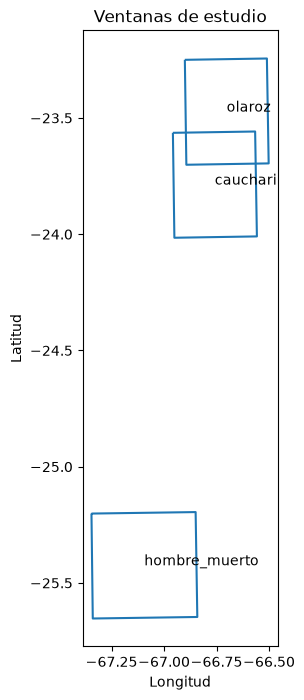

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

for salar_key, salar in SALARES.items():
    aoi, _ = build_rectangular_aoi(salar)

    aoi.boundary.plot(ax=ax)

    centroid = aoi.geometry.iloc[0].centroid

    ax.text(
        centroid.x,
        centroid.y,
        salar_key,
        fontsize=10,
    )

ax.set_title("Ventanas de estudio")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.show()

## 5.2. Control de superposición entre AOI

Para experimentos de transferencia entre dominios conviene comprobar que las ventanas de estudio no se superpongan de forma accidental.

La superposición no es necesariamente un error para la descarga, pero sí puede producir **fuga espacial** si se entrena con muestras de un salar y se evalúa sobre píxeles del otro dentro de la zona compartida.


In [10]:
def build_aoi_overlap_table(
    salares: dict,
) -> pd.DataFrame:

    aoi_by_key = {}

    for salar_key, salar in salares.items():
        aoi, epsg = build_rectangular_aoi(salar)

        aoi_by_key[salar_key] = (
            aoi.to_crs(epsg).geometry.iloc[0],
            epsg,
        )

    rows = []
    keys = list(salares)

    for i, key_a in enumerate(keys):
        geom_a, epsg_a = aoi_by_key[key_a]

        for key_b in keys[i + 1:]:
            aoi_b, _ = build_rectangular_aoi(salares[key_b])
            geom_b = aoi_b.to_crs(epsg_a).geometry.iloc[0]

            overlap_km2 = (
                geom_a
                .intersection(geom_b)
                .area
                / 1_000_000.0
            )

            pct_a = (
                100.0
                * overlap_km2
                / (geom_a.area / 1_000_000.0)
            )

            pct_b = (
                100.0
                * overlap_km2
                / (geom_b.area / 1_000_000.0)
            )

            rows.append({
                "aoi_a": key_a,
                "aoi_b": key_b,
                "overlap_km2": overlap_km2,
                "overlap_pct_a": pct_a,
                "overlap_pct_b": pct_b,
            })

    return pd.DataFrame(rows)


aoi_overlap_df = build_aoi_overlap_table(SALARES)
aoi_overlap_df


,aoi_a,aoi_b,overlap_km2,overlap_pct_a,overlap_pct_b
0,olaroz,cauchari,515.675554,25.783778,25.783778
1,olaroz,hombre_muerto,0.000000,0.000000,0.000000
2,cauchari,hombre_muerto,0.000000,0.000000,0.000000


# 6. Consulta al catálogo STAC

El catálogo se consulta por colección, AOI y rango temporal.

La nubosidad `eo:cloud_cover` se filtra **localmente** después de recuperar los items. Esto evita depender de la extensión STAC `QUERY`, que Planetary Computer puede no declarar como soportada aunque el cliente permita enviar ese parámetro.

La máscara real de nubes y sombras se aplica después, por píxel, usando SCL.


In [11]:
STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"


def _item_date(item) -> str:
    return str(item.properties.get("datetime", ""))[:10]


def search_items(
    aoi_wgs84: gpd.GeoDataFrame,
    cfg: PipelineConfig,
):
    """
    Consulta STAC por colección, geometría y fecha.

    La nubosidad se filtra localmente para no depender de la extensión QUERY.
    La salida se ordena de forma determinista por datetime + item_id.
    """
    catalog = Client.open(STAC_URL)

    search = catalog.search(
        collections=[cfg.collection],
        intersects=mapping(aoi_wgs84.geometry.iloc[0]),
        datetime=cfg.date_range,
        max_items=cfg.stac_max_items,
    )

    raw_items = list(search.items())

    if not raw_items:
        raise RuntimeError(
            "No se encontraron escenas Sentinel-2 para el AOI y "
            "el rango temporal seleccionado."
        )

    items = []
    missing_cloud = 0

    for item in raw_items:
        cloud = item.properties.get("eo:cloud_cover")

        if cloud is None:
            missing_cloud += 1
            continue

        try:
            cloud = float(cloud)
        except (TypeError, ValueError):
            missing_cloud += 1
            continue

        if cloud < cfg.max_scene_cloud:
            items.append(item)

    if missing_cloud:
        warnings.warn(
            f"{missing_cloud} items STAC no tenían eo:cloud_cover válido "
            "y fueron excluidos del filtro de candidatos."
        )

    if not items:
        raise RuntimeError(
            "Se encontraron escenas en STAC, pero ninguna cumple "
            f"eo:cloud_cover < {cfg.max_scene_cloud:.1f}%."
        )

    items.sort(
        key=lambda item: (
            str(item.properties.get("datetime", "")),
            item.id,
        )
    )

    return items


def item_table(items) -> pd.DataFrame:
    rows = []

    for item in items:
        properties = item.properties

        rows.append({
            "item_id": item.id,
            "datetime": properties.get("datetime"),
            "date": _item_date(item),
            "platform": properties.get("platform"),
            "mgrs_tile": (
                properties.get("s2:mgrs_tile")
                or properties.get("mgrs:tile")
            ),
            "eo_cloud_cover": properties.get("eo:cloud_cover"),
            "processing_baseline": properties.get("s2:processing_baseline"),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(["date", "item_id"], kind="stable")
        .reset_index(drop=True)
        if rows else pd.DataFrame()
    )


# 7. Cobertura geométrica por fecha

Un AOI puede cruzar varios tiles Sentinel-2.

Por eso agrupamos los items por fecha y calculamos la cobertura del AOI usando la unión de sus footprints.

In [12]:
def coverage_by_date(
    items,
    aoi_wgs84: gpd.GeoDataFrame,
    target_epsg: int,
) -> pd.DataFrame:

    aoi_geom_utm = aoi_wgs84.to_crs(target_epsg).geometry.iloc[0]
    aoi_area = aoi_geom_utm.area

    by_date = defaultdict(list)

    for item in items:
        date = _item_date(item)
        if date:
            by_date[date].append(item)

    rows = []

    for date in sorted(by_date):
        date_items = by_date[date]

        footprints = [
            shape(item.geometry)
            for item in date_items
            if item.geometry is not None
        ]

        if footprints:
            union_wgs84 = unary_union(footprints)
            union_utm = (
                gpd.GeoSeries([union_wgs84], crs="EPSG:4326")
                .to_crs(target_epsg)
                .iloc[0]
            )
            covered_area = union_utm.intersection(aoi_geom_utm).area
            coverage_pct = 100.0 * covered_area / aoi_area
            coverage_pct = float(np.clip(coverage_pct, 0.0, 100.0))
        else:
            coverage_pct = 0.0

        cloud_values = []
        for item in date_items:
            value = item.properties.get("eo:cloud_cover")
            if value is not None:
                try:
                    cloud_values.append(float(value))
                except (TypeError, ValueError):
                    pass

        tiles = sorted({
            str(
                item.properties.get("s2:mgrs_tile")
                or item.properties.get("mgrs:tile")
                or ""
            )
            for item in date_items
        })

        rows.append({
            "date": date,
            "n_items": len(date_items),
            "coverage_pct": coverage_pct,
            "mean_scene_cloud": (
                float(np.mean(cloud_values)) if cloud_values else np.nan
            ),
            "max_scene_cloud": (
                float(np.max(cloud_values)) if cloud_values else np.nan
            ),
            "tiles": ";".join(tiles),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    return (
        df.sort_values(
            ["coverage_pct", "mean_scene_cloud", "date"],
            ascending=[False, True, True],
            kind="stable",
        )
        .reset_index(drop=True)
    )


# 8. Selección automática de fechas

Criterios:

1. priorizar fechas con cobertura geométrica suficiente;
2. priorizar menor nubosidad promedio;
3. mantener separación temporal mínima;
4. garantizar al menos `min_dates`.

In [13]:
def select_dates(
    coverage_df: pd.DataFrame,
    cfg: PipelineConfig,
) -> list[str]:

    if coverage_df.empty:
        raise RuntimeError("No hay fechas candidatas para seleccionar.")

    ranked = coverage_df.copy()
    ranked["full_enough"] = ranked["coverage_pct"] >= cfg.coverage_target_pct

    ranked = ranked.sort_values(
        ["full_enough", "coverage_pct", "mean_scene_cloud", "date"],
        ascending=[False, False, True, True],
        kind="stable",
    )

    selected: list[pd.Timestamp] = []

    for date_text in ranked["date"]:
        date = pd.Timestamp(date_text)
        sufficiently_far = all(
            abs((date - previous).days) >= cfg.min_days_apart
            for previous in selected
        )

        if sufficiently_far:
            selected.append(date)

        if len(selected) >= cfg.max_dates:
            break

    if len(selected) < cfg.min_dates:
        for date_text in ranked["date"]:
            date = pd.Timestamp(date_text)
            if date not in selected:
                selected.append(date)
            if len(selected) >= cfg.min_dates:
                break

    selected_dates = sorted(date.strftime("%Y-%m-%d") for date in selected)

    selected_coverage = (
        coverage_df.set_index("date")
        .reindex(selected_dates)["coverage_pct"]
    )

    below_target = selected_coverage[
        selected_coverage < cfg.coverage_target_pct
    ]

    if not below_target.empty:
        warnings.warn(
            "Algunas fechas seleccionadas no alcanzan "
            f"{cfg.coverage_target_pct:.1f}% de cobertura del AOI: "
            + ", ".join(
                f"{date}={value:.2f}%"
                for date, value in below_target.items()
            )
        )

    return selected_dates


def items_for_dates(items, selected_dates: list[str]):
    wanted = set(selected_dates)
    selected = [item for item in items if _item_date(item) in wanted]
    selected.sort(key=lambda item: (_item_date(item), item.id))
    return selected


def group_items_by_date(items) -> dict[str, list]:
    grouped = defaultdict(list)
    for item in items:
        date = _item_date(item)
        if date:
            grouped[date].append(item)

    return {
        date: sorted(date_items, key=lambda item: item.id)
        for date, date_items in sorted(grouped.items())
    }


def validate_required_assets(items, cfg: PipelineConfig):
    required = set(cfg.spectral_bands) | {"SCL"}
    problems = {}

    for item in items:
        missing = sorted(required - set(item.assets))
        if missing:
            problems[item.id] = missing

    if problems:
        preview = list(problems.items())[:8]
        raise RuntimeError(
            "Hay STAC Items sin assets requeridos. Ejemplos: "
            f"{preview}"
        )


# 9. Construcción de stacks remotos por fecha

`stackstac.stack` crea arreglos **lazy**: construir el stack no descarga el raster; el I/O ocurre al materializar con Dask.

En v5 nunca se apilan todas las fechas en un único cálculo remoto. `build_stacks()` recibe sólo los items de **una fecha**, obtiene copias STAC frescas, firma los assets inmediatamente antes del cómputo y recorta en los bounds UTM exactos del AOI.

Esto reduce drásticamente la ventana temporal durante la cual un SAS debe seguir siendo válido.


In [14]:
def refresh_and_sign_items(selected_items, collection: str):
    """Recupera Items limpios por ID y firma sus assets justo antes del I/O."""
    item_ids = [item.id for item in selected_items]

    if not item_ids:
        raise ValueError("No hay items para firmar.")

    catalog = Client.open(STAC_URL)
    search = catalog.search(
        collections=[collection],
        ids=item_ids,
        max_items=len(item_ids),
    )

    fresh_items = list(search.items())
    fresh_by_id = {item.id: item for item in fresh_items}

    missing = [item_id for item_id in item_ids if item_id not in fresh_by_id]
    if missing:
        raise RuntimeError(
            "No se pudieron recuperar nuevamente los STAC Items: "
            f"{missing}"
        )

    fresh_items = [fresh_by_id[item_id] for item_id in item_ids]
    return [pc.sign(item) for item in fresh_items]


def min_signed_sas_ttl_minutes(
    signed_items,
    asset_names: tuple[str, ...] | list[str],
) -> float | None:
    """Extrae el `se=` de URLs firmadas sin imprimir ni persistir el SAS."""
    expiries = []

    for item in signed_items:
        for asset_name in asset_names:
            asset = item.assets.get(asset_name)
            if asset is None or not asset.href:
                continue

            try:
                query = parse_qs(urlsplit(asset.href).query)
                expiry_text = query.get("se", [None])[0]
                if not expiry_text:
                    continue
                expiry = datetime.fromisoformat(
                    expiry_text.replace("Z", "+00:00")
                )
                expiries.append(expiry.astimezone(timezone.utc))
            except Exception:
                continue

    if not expiries:
        return None

    now = datetime.now(timezone.utc)
    return min((expiry - now).total_seconds() / 60.0 for expiry in expiries)


In [15]:
def build_stacks(
    selected_items,
    aoi_wgs84: gpd.GeoDataFrame,
    target_epsg: int,
    cfg: PipelineConfig,
):
    """Construye stacks lazy para UNA fecha con SAS frescos."""
    if not selected_items:
        raise ValueError("selected_items está vacío.")

    signed = refresh_and_sign_items(
        selected_items,
        collection=cfg.collection,
    )

    ttl_minutes = min_signed_sas_ttl_minutes(
        signed,
        [*cfg.spectral_bands, "SCL"],
    )

    bounds = tuple(
        aoi_wgs84.to_crs(target_epsg).total_bounds.tolist()
    )

    gdal_env = build_gdal_env(cfg)

    spectral = stackstac.stack(
        signed,
        assets=list(cfg.spectral_bands),
        bounds=bounds,
        epsg=target_epsg,
        resolution=cfg.resolution_m,
        dtype=np.dtype("float64"),
        fill_value=np.float64(np.nan),
        rescale=True,
        resampling=Resampling.bilinear,
        chunksize=cfg.remote_chunksize,
        band_coords=False,
        properties=False,
        gdal_env=gdal_env,
    ).astype(np.float32)

    scl = stackstac.stack(
        signed,
        assets=["SCL"],
        bounds=bounds,
        epsg=target_epsg,
        resolution=cfg.resolution_m,
        dtype=np.dtype("float64"),
        fill_value=np.float64(np.nan),
        rescale=False,
        resampling=Resampling.nearest,
        chunksize=cfg.remote_chunksize,
        band_coords=False,
        properties=False,
        gdal_env=gdal_env,
    )

    scl = scl.sel(band="SCL").astype(np.float32)
    return spectral, scl, ttl_minutes


# 10. Limpieza defensiva de coordenadas auxiliares

Aunque `band_coords=False` evita el principal problema, conviene limpiar coordenadas auxiliares antes de combinar bandas e índices.

Esto evita errores como:

```text
ValueError: coordinate 'common_name' not present in all datasets
```

In [16]:
def clean_auxiliary_coords(
    da: xr.DataArray,
) -> xr.DataArray:
    return da.reset_coords(
        drop=True
    )

# 11. Máscara SCL y mosaico diario

La unidad remota de trabajo es ahora **una fecha**.

Para cada adquisición de esa fecha:

```text
bandas + SCL
    ↓
SCL válido y 10 bandas finitas
    ↓
máscara por adquisición
    ↓
mediana entre items/tiles de ESA fecha
    ↓
GeoTIFF diario local + máscara diaria válida
```

La mediana entre fechas se realiza después y exclusivamente desde archivos locales.


In [17]:
def scl_valid_mask(
    scl: xr.DataArray,
    cfg: PipelineConfig,
) -> xr.DataArray:
    invalid = xr.zeros_like(scl, dtype=bool)

    for scl_value in cfg.invalid_scl:
        invalid = invalid | (scl == scl_value)

    return (~invalid) & np.isfinite(scl)


In [18]:
def daily_composite_lazy(
    spectral: xr.DataArray,
    scl: xr.DataArray,
    cfg: PipelineConfig,
) -> tuple[xr.DataArray, xr.DataArray]:
    """Mosaico de una única fecha a partir de sus items/tiles."""
    valid_scl = scl_valid_mask(scl, cfg)
    valid_spectral = np.isfinite(spectral).all(dim="band")
    valid = valid_scl & valid_spectral

    spectral_masked = spectral.where(valid)

    daily = spectral_masked.median(
        dim="time",
        skipna=True,
    ).astype(np.float32)

    daily_valid = (
        valid.any(dim="time")
        & np.isfinite(daily).all(dim="band")
    )

    return daily, daily_valid.astype(np.uint8)


# 12. Índices espectrales

Se agregan cinco atributos derivados:

- NDVI
- NDWI
- MNDWI
- NDMI
- BSI

Para ML clásico conviene luego comparar:

1. sólo bandas;
2. bandas + índices.

Así podemos medir si realmente aportan información.

In [19]:
def safe_ratio(
    numerator: xr.DataArray,
    denominator: xr.DataArray,
) -> xr.DataArray:

    return xr.where(
        np.abs(denominator) > 1e-6,
        numerator / denominator,
        np.nan,
    )

In [20]:
def spectral_indices(
    mosaic: xr.DataArray,
) -> xr.DataArray:

    # Limpieza defensiva.
    mosaic = clean_auxiliary_coords(
        mosaic
    )

    # Seleccionar cada banda y eliminar la coordenada
    # escalar "band" resultante.
    b = {
        name: mosaic.sel(
            band=name,
            drop=True,
        )
        for name in mosaic.band.values.tolist()
    }

    # NDVI
    ndvi = safe_ratio(
        b["B08"] - b["B04"],
        b["B08"] + b["B04"],
    )

    # NDWI
    ndwi = safe_ratio(
        b["B03"] - b["B08"],
        b["B03"] + b["B08"],
    )

    # MNDWI
    mndwi = safe_ratio(
        b["B03"] - b["B11"],
        b["B03"] + b["B11"],
    )

    # NDMI
    ndmi = safe_ratio(
        b["B08"] - b["B11"],
        b["B08"] + b["B11"],
    )

    # BSI
    bsi_num = (
        (b["B11"] + b["B04"])
        - (b["B08"] + b["B02"])
    )

    bsi_den = (
        (b["B11"] + b["B04"])
        + (b["B08"] + b["B02"])
    )

    bsi = safe_ratio(
        bsi_num,
        bsi_den,
    )

    indices = xr.concat(
        [
            ndvi,
            ndwi,
            mndwi,
            ndmi,
            bsi,
        ],
        dim=pd.Index(
            [
                "NDVI",
                "NDWI",
                "MNDWI",
                "NDMI",
                "BSI",
            ],
            name="band",
        ),
        coords="minimal",
        compat="override",
        combine_attrs="drop",
    )

    return indices.astype(
        np.float32
    )

# 13. Combinar bandas e índices

La concatenación se hace de forma defensiva para evitar conflictos de metadatos de `xarray`.

In [21]:
def build_feature_cube(
    mosaic: xr.DataArray,
) -> tuple[xr.DataArray, xr.DataArray]:

    mosaic_clean = clean_auxiliary_coords(
        mosaic
    )

    indices = spectral_indices(
        mosaic_clean
    )

    features = xr.concat(
        [
            mosaic_clean,
            indices,
        ],
        dim="band",
        coords="minimal",
        compat="override",
        combine_attrs="drop",
    )

    features = features.astype(
        np.float32
    )

    return features, indices

# 14. Preparación y exportación GeoTIFF

In [22]:
def prepare_spatial(
    da: xr.DataArray,
    epsg: int,
    banded: bool = True,
) -> xr.DataArray:

    da = da.rio.set_spatial_dims(
        x_dim="x",
        y_dim="y",
        inplace=False,
    )

    da = da.rio.write_crs(
        f"EPSG:{epsg}",
        inplace=False,
    )

    if banded:

        if "band" not in da.dims:
            da = da.expand_dims(
                band=["value"]
            )

        da = da.transpose(
            "band",
            "y",
            "x",
        )

    else:

        da = da.transpose(
            "y",
            "x",
        )

    return da

In [23]:
def _validation_windows(src, n: int = 5) -> list[Window]:
    size = int(max(1, min(32, src.width, src.height)))

    anchors = [
        (0, 0),
        (max(0, src.width - size), 0),
        (0, max(0, src.height - size)),
        (max(0, src.width - size), max(0, src.height - size)),
        (
            max(0, (src.width - size) // 2),
            max(0, (src.height - size) // 2),
        ),
    ]

    return [
        Window(col_off=x, row_off=y, width=size, height=size)
        for x, y in anchors[:max(1, min(n, len(anchors)))]
    ]


def validate_raster(
    path: Path,
    expected_count: int | None = None,
    expected_epsg: int | None = None,
    expected_band_names: list[str] | tuple[str, ...] | None = None,
    expected_dtype: str | None = None,
    sample_windows: int = 5,
) -> tuple[bool, str, dict]:
    """Validación estructural + lecturas distribuidas del GeoTIFF."""
    path = Path(path)

    if not path.exists():
        return False, "missing", {}

    try:
        with rasterio.open(path) as src:
            if src.width <= 0 or src.height <= 0 or src.count <= 0:
                return False, "invalid_shape", {}

            if expected_count is not None and src.count != expected_count:
                return False, f"count={src.count}", {}

            if expected_epsg is not None:
                got_epsg = src.crs.to_epsg() if src.crs else None
                if got_epsg != expected_epsg:
                    return False, f"epsg={got_epsg}", {}

            if expected_dtype is not None:
                if any(np.dtype(dtype).name != np.dtype(expected_dtype).name for dtype in src.dtypes):
                    return False, f"dtype={src.dtypes}", {}

            if expected_band_names is not None:
                expected = tuple(str(x) for x in expected_band_names)
                got = tuple(src.descriptions)
                if got != expected:
                    return False, f"band_descriptions={got}", {}

            bands_to_probe = sorted({1, src.count})
            for window in _validation_windows(src, sample_windows):
                for band in bands_to_probe:
                    src.read(band, window=window)

            info = {
                "width": src.width,
                "height": src.height,
                "count": src.count,
                "crs": str(src.crs),
                "epsg": src.crs.to_epsg() if src.crs else None,
                "transform": tuple(src.transform),
                "dtypes": tuple(src.dtypes),
                "nodata": src.nodata,
                "descriptions": tuple(src.descriptions),
            }

        return True, "ok", info

    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}", {}


def write_raster(
    da: xr.DataArray,
    path: Path,
    epsg: int,
    band_names: list[str] | None = None,
    nodata=None,
):
    """Escritura atómica: sólo publica el destino tras validarlo."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    tmp_path = path.with_name(
        f".{path.name}.{uuid.uuid4().hex}.tmp.tif"
    )

    banded = "band" in da.dims
    out = prepare_spatial(da, epsg, banded=banded)

    if band_names is not None:
        expected = int(out.sizes.get("band", 1))
        if len(band_names) != expected:
            raise ValueError(
                "La cantidad de band_names no coincide con las bandas del raster: "
                f"{len(band_names)} != {expected}"
            )

    if nodata is not None:
        out = out.rio.write_nodata(nodata, inplace=False)

    dtype = np.dtype(out.dtype)
    predictor = 3 if np.issubdtype(dtype, np.floating) else 2

    try:
        out.rio.to_raster(
            tmp_path,
            compress="DEFLATE",
            predictor=predictor,
            tiled=True,
            blockxsize=512,
            blockysize=512,
            BIGTIFF="IF_SAFER",
            num_threads="ALL_CPUS",
        )

        if band_names:
            with rasterio.open(tmp_path, "r+") as dst:
                for index, name in enumerate(band_names, start=1):
                    dst.set_band_description(index, str(name))

        ok, reason, _ = validate_raster(
            tmp_path,
            expected_count=int(out.sizes.get("band", 1)) if banded else 1,
            expected_epsg=epsg,
            expected_band_names=band_names,
            sample_windows=5,
        )
        if not ok:
            raise RuntimeError(f"GeoTIFF temporal inválido: {reason}")

        os.replace(tmp_path, path)

    except BaseException:
        try:
            tmp_path.unlink(missing_ok=True)
        except Exception:
            pass
        raise

    return path


def raster_is_readable(
    path: Path,
    expected_count: int | None = None,
) -> bool:
    ok, _, _ = validate_raster(
        path,
        expected_count=expected_count,
        sample_windows=3,
    )
    return ok


# 15. Validación numérica básica

Antes de etiquetar o entrenar modelos, verificamos:

- número de fechas;
- porcentaje de píxeles sin datos válidos;
- cuantiles de la primera banda;
- rango aproximado de reflectancia.

In [24]:
def summarize_product(
    mosaic: xr.DataArray,
    valid_count: xr.DataArray,
    n_dates: int,
):

    first_band = mosaic.isel(
        band=0
    )

    total_pixels = int(
        first_band.sizes["x"]
        * first_band.sizes["y"]
    )

    no_valid = int(
        (valid_count == 0)
        .sum()
        .compute()
    )

    no_valid_pct = (
        100.0
        * no_valid
        / total_pixels
    )

    q01 = float(
        first_band
        .quantile(
            0.01,
            skipna=True,
        )
        .compute()
    )

    q50 = float(
        first_band
        .quantile(
            0.50,
            skipna=True,
        )
        .compute()
    )

    q99 = float(
        first_band
        .quantile(
            0.99,
            skipna=True,
        )
        .compute()
    )

    print(
        f"Fechas usadas: {n_dates}"
    )

    print(
        "Píxeles sin observaciones válidas: "
        f"{no_valid_pct:.3f}%"
    )

    print(
        "Cuantiles banda 1: "
        f"p01={q01:.4f}, "
        f"p50={q50:.4f}, "
        f"p99={q99:.4f}"
    )

    if q99 > 2.0:
        warnings.warn(
            "Los valores parecen demasiado altos para reflectancia "
            "reescalada. Revisar scale/offset de los assets STAC."
        )

# 16. Arquitectura incremental y reanudable

La versión anterior materializaba todas las fechas dentro de un único grafo Dask. Si el SAS expiraba al 64 %, el retry reconstruía todo desde 0 %.

La v5 divide el trabajo en checkpoints durables:

```text
fecha 1 → SAS fresco → mosaico diario → cache local ✓
fecha 2 → SAS fresco → mosaico diario → cache local ✓
fecha 3 → SAS fresco → mosaico diario → cache local ✓
...
                         ↓
             composición temporal LOCAL
                         ↓
               features + GeoTIFF finales
```

Un cache diario sólo se considera válido si existe su manifest, el fingerprint coincide con la configuración/items esperados y los rasters pasan validación estructural y lecturas distribuidas.


## 16.1. Cache transaccional, fingerprints, bitácora y validación

Cada fecha genera:

- `YYYY-MM-DD_spectral.tif`
- `YYYY-MM-DD_valid_mask.tif`
- `YYYY-MM-DD_manifest.json`

El manifest se escribe **último**. Si Jupyter se interrumpe antes, la fecha queda incompleta y en la próxima ejecución se reconstruye automáticamente.


In [25]:
_TRANSIENT_REMOTE_MARKERS = (
    "TIFFFillTile",
    "TIFFReadEncodedTile",
    "IReadBlock failed",
    "Read failed",
    "Error reading Window",
    "Error opening",
    "HTTP response code",
    "CURL",
    "curl",
    "Connection reset",
    "connection reset",
    "Timeout",
    "timed out",
    "SSL",
    "Temporary failure",
    "Connection aborted",
)

_SENSITIVE_QUERY_KEYS = (
    "sig", "se", "sp", "sv", "sr", "skt", "ske",
    "skoid", "sktid", "sks", "skv",
)


class RemoteDateProcessingError(RuntimeError):
    """Una o más fechas no pudieron materializarse por I/O remoto."""


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def stable_fingerprint(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    ).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def write_json_atomic(path: Path, payload: dict):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_name(f".{path.name}.{uuid.uuid4().hex}.tmp")

    try:
        with open(tmp, "w", encoding="utf-8") as file:
            json.dump(payload, file, ensure_ascii=False, indent=2, default=str)
            file.flush()
            os.fsync(file.fileno())
        os.replace(tmp, path)
    except BaseException:
        try:
            tmp.unlink(missing_ok=True)
        except Exception:
            pass
        raise


def append_event(log_path: Path, event: str, **data):
    log_path.parent.mkdir(parents=True, exist_ok=True)
    record = {
        "timestamp_utc": utc_now_iso(),
        "event": event,
        **data,
    }
    with open(log_path, "a", encoding="utf-8") as file:
        file.write(json.dumps(record, ensure_ascii=False, default=str) + "\n")


def sanitize_remote_error(exc: Exception, max_chars: int = 1200) -> str:
    """Evita que una URL SAS completa quede expuesta en notebook/logs."""
    text = f"{type(exc).__name__}: {exc}"

    def redact_url(match):
        url = match.group(0)
        if "?" in url:
            return url.split("?", 1)[0] + "?<SAS_REDACTED>"
        return url

    text = re.sub(r"https?://[^\s'\"<>]+", redact_url, text)

    for key in _SENSITIVE_QUERY_KEYS:
        text = re.sub(
            rf"(?i)({re.escape(key)}=)[^&\s'\"]+",
            rf"\1<REDACTED>",
            text,
        )

    return text[-max_chars:]


def is_transient_remote_error(exc: Exception) -> bool:
    text = f"{type(exc).__name__}: {exc}"
    return any(marker in text for marker in _TRANSIENT_REMOTE_MARKERS)


def classify_remote_error(exc: Exception) -> str:
    text = f"{type(exc).__name__}: {exc}".lower()
    if "403" in text:
        return "http_403_sas_or_auth"
    if "429" in text:
        return "http_429_rate_limit"
    if "timeout" in text or "timed out" in text:
        return "timeout"
    if "ssl" in text:
        return "ssl"
    if "tiff" in text or "ireadblock" in text:
        return "remote_raster_io"
    return "remote_io"


def scientific_cache_payload(
    date: str,
    date_items,
    aoi: gpd.GeoDataFrame,
    epsg: int,
    cfg: PipelineConfig,
) -> dict:
    bounds_utm = [
        round(float(value), 6)
        for value in aoi.to_crs(epsg).total_bounds.tolist()
    ]

    return {
        "cache_schema_version": cfg.cache_schema_version,
        "pipeline_version": cfg.pipeline_version,
        "collection": cfg.collection,
        "date": date,
        "item_ids": sorted(item.id for item in date_items),
        "epsg": epsg,
        "bounds_utm": bounds_utm,
        "resolution_m": cfg.resolution_m,
        "spectral_bands": list(cfg.spectral_bands),
        "invalid_scl": list(cfg.invalid_scl),
        "spectral_resampling": "bilinear",
        "scl_resampling": "nearest",
        "rescale_spectral": True,
        "daily_reducer": "median_valid_pixels_across_items",
    }


def daily_cache_paths(salar_key: str, date: str) -> dict[str, Path]:
    folder = CACHE_DIR / salar_key / "daily"
    folder.mkdir(parents=True, exist_ok=True)

    return {
        "spectral": folder / f"{date}_spectral.tif",
        "valid_mask": folder / f"{date}_valid_mask.tif",
        "manifest": folder / f"{date}_manifest.json",
    }


def purge_daily_cache(paths: dict[str, Path]):
    for path in paths.values():
        try:
            Path(path).unlink(missing_ok=True)
        except Exception as exc:
            warnings.warn(f"No se pudo eliminar cache inválido {path}: {exc}")


def validate_daily_cache(
    paths: dict[str, Path],
    expected_fingerprint: str,
    epsg: int,
    cfg: PipelineConfig,
) -> tuple[bool, str, dict | None]:
    manifest_path = paths["manifest"]

    if not manifest_path.exists():
        return False, "manifest_missing", None

    try:
        with open(manifest_path, "r", encoding="utf-8") as file:
            manifest = json.load(file)
    except Exception as exc:
        return False, f"manifest_invalid:{type(exc).__name__}", None

    if manifest.get("status") != "complete":
        return False, "manifest_not_complete", manifest

    if manifest.get("fingerprint") != expected_fingerprint:
        return False, "fingerprint_mismatch", manifest

    spectral_ok, spectral_reason, spectral_info = validate_raster(
        paths["spectral"],
        expected_count=len(cfg.spectral_bands),
        expected_epsg=epsg,
        expected_band_names=list(cfg.spectral_bands),
        expected_dtype="float32",
        sample_windows=cfg.raster_validation_windows,
    )
    if not spectral_ok:
        return False, f"spectral:{spectral_reason}", manifest

    valid_ok, valid_reason, valid_info = validate_raster(
        paths["valid_mask"],
        expected_count=1,
        expected_epsg=epsg,
        expected_dtype="uint8",
        sample_windows=cfg.raster_validation_windows,
    )
    if not valid_ok:
        return False, f"valid_mask:{valid_reason}", manifest

    if (
        spectral_info["width"] != valid_info["width"]
        or spectral_info["height"] != valid_info["height"]
        or spectral_info["transform"] != valid_info["transform"]
    ):
        return False, "grid_mismatch", manifest

    return True, "ok", manifest


def estimate_uncompressed_working_gb(
    aoi: gpd.GeoDataFrame,
    epsg: int,
    n_dates: int,
    cfg: PipelineConfig,
) -> dict:
    minx, miny, maxx, maxy = aoi.to_crs(epsg).total_bounds
    width = int(math.ceil((maxx - minx) / cfg.resolution_m))
    height = int(math.ceil((maxy - miny) / cfg.resolution_m))
    pixels = width * height

    daily_bytes = pixels * (len(cfg.spectral_bands) * 4 + 1)
    all_daily_bytes = daily_bytes * n_dates
    final_bytes = pixels * (
        len(cfg.spectral_bands) * 4
        + (len(cfg.spectral_bands) + 5) * 4
        + 2
        + 4
    )

    gib = 1024 ** 3
    return {
        "width": width,
        "height": height,
        "pixels": pixels,
        "daily_uncompressed_gib": daily_bytes / gib,
        "all_daily_uncompressed_gib": all_daily_bytes / gib,
        "final_uncompressed_gib": final_bytes / gib,
    }


def warn_disk_space(base_dir: Path, cfg: PipelineConfig):
    usage = shutil.disk_usage(base_dir)
    free_gb = usage.free / (1024 ** 3)
    print(f"Espacio libre aproximado: {free_gb:.1f} GiB")
    if free_gb < cfg.warn_free_disk_gb:
        warnings.warn(
            f"Quedan sólo {free_gb:.1f} GiB libres. El cache diario puede "
            "necesitar varios GiB durante el procesamiento."
        )


## 16.2. Checkpoint remoto por fecha

Cada fecha tiene retries independientes. Si una fecha falla definitivamente, las fechas ya completadas quedan en disco. El siguiente `process_salar(...)` las detecta como **CACHE HIT** y continúa desde la faltante.

In [26]:

def compute_one_date_with_retry(
    date: str,
    date_items,
    aoi: gpd.GeoDataFrame,
    epsg: int,
    cfg: PipelineConfig,
    log_path: Path,
):
    last_error = None

    for attempt in range(1, cfg.date_remote_max_attempts + 1):
        print()
        print(
            f"    {date} | intento remoto "
            f"{attempt}/{cfg.date_remote_max_attempts}"
        )
        append_event(
            log_path,
            "date_attempt_started",
            date=date,
            attempt=attempt,
            item_count=len(date_items),
        )

        attempt_started = time.perf_counter()

        try:
            spectral, scl, ttl_minutes = build_stacks(
                date_items,
                aoi,
                epsg,
                cfg,
            )

            if ttl_minutes is not None:
                print(f"    SAS TTL mínimo al iniciar: {ttl_minutes:.1f} min")
                if ttl_minutes < 10:
                    warnings.warn(
                        f"TTL SAS muy corto ({ttl_minutes:.1f} min) para {date}."
                    )

            daily, daily_valid = daily_composite_lazy(
                spectral,
                scl,
                cfg,
            )

            with warnings.catch_warnings():
                warnings.filterwarnings(
                    "ignore",
                    message="All-NaN slice encountered",
                    category=RuntimeWarning,
                )

                with ProgressBar():
                    daily_data, valid_data = dask.compute(
                        daily.data,
                        daily_valid.data,
                        scheduler="threads",
                        num_workers=cfg.remote_num_workers,
                    )

            daily_local = daily.copy(data=daily_data.astype(np.float32, copy=False))
            valid_local = daily_valid.copy(data=valid_data.astype(np.uint8, copy=False))

            elapsed_s = time.perf_counter() - attempt_started
            valid_pct = float(np.mean(valid_data == 1) * 100.0)

            del spectral, scl, daily, daily_valid
            gc.collect()

            append_event(
                log_path,
                "date_attempt_completed",
                date=date,
                attempt=attempt,
                elapsed_s=elapsed_s,
                valid_pixel_pct=valid_pct,
                sas_ttl_minutes_at_start=ttl_minutes,
            )

            return daily_local, valid_local, {
                "attempts_used": attempt,
                "elapsed_s": elapsed_s,
                "valid_pixel_pct": valid_pct,
                "sas_ttl_minutes_at_start": ttl_minutes,
            }

        except Exception as exc:
            last_error = exc

            if not is_transient_remote_error(exc):
                append_event(
                    log_path,
                    "date_non_remote_failure",
                    date=date,
                    attempt=attempt,
                    error=sanitize_remote_error(exc),
                )
                raise

            category = classify_remote_error(exc)
            sanitized = sanitize_remote_error(exc)

            print(f"    fallo remoto [{category}]")
            print("    " + sanitized.replace("\n", " ")[:1000])

            append_event(
                log_path,
                "date_remote_failure",
                date=date,
                attempt=attempt,
                category=category,
                error=sanitized,
            )

            gc.collect()

            if attempt >= cfg.date_remote_max_attempts:
                break

            delay = min(
                cfg.remote_retry_base_delay_s * (2 ** (attempt - 1)),
                60,
            )

            if category == "http_403_sas_or_auth":
                print(
                    f"    403 detectado: se obtendrán STAC Items + SAS nuevos "
                    f"en {delay} s."
                )
            else:
                print(f"    reintentando con grafo nuevo en {delay} s...")

            time.sleep(delay)

    raise RemoteDateProcessingError(
        f"La fecha {date} no pudo completarse después de "
        f"{cfg.date_remote_max_attempts} intentos. Las otras fechas "
        "ya cacheadas se conservaron."
    ) from last_error


def materialize_date_to_cache(
    salar_key: str,
    date: str,
    date_items,
    aoi: gpd.GeoDataFrame,
    epsg: int,
    cfg: PipelineConfig,
    log_path: Path,
) -> dict:
    payload = scientific_cache_payload(date, date_items, aoi, epsg, cfg)
    fingerprint = stable_fingerprint(payload)
    paths = daily_cache_paths(salar_key, date)

    cache_ok, reason, manifest = validate_daily_cache(
        paths,
        fingerprint,
        epsg,
        cfg,
    )

    if cache_ok:
        print(f"  [{date}] CACHE HIT ✓")
        append_event(
            log_path,
            "daily_cache_hit",
            date=date,
            fingerprint=fingerprint,
        )
        return manifest

    if any(Path(path).exists() for path in paths.values()):
        print(f"  [{date}] cache inválido ({reason}); se reconstruye.")
        append_event(
            log_path,
            "daily_cache_invalidated",
            date=date,
            reason=reason,
        )
        purge_daily_cache(paths)
    else:
        print(f"  [{date}] cache ausente; procesando...")

    started = time.perf_counter()

    daily_local, valid_local, attempt_meta = compute_one_date_with_retry(
        date=date,
        date_items=date_items,
        aoi=aoi,
        epsg=epsg,
        cfg=cfg,
        log_path=log_path,
    )

    write_raster(
        daily_local,
        paths["spectral"],
        epsg,
        band_names=list(cfg.spectral_bands),
        nodata=np.nan,
    )

    write_raster(
        valid_local,
        paths["valid_mask"],
        epsg,
        nodata=np.uint8(255),
    )

    total_elapsed_s = time.perf_counter() - started

    manifest = {
        "status": "complete",
        "created_utc": utc_now_iso(),
        "pipeline_version": cfg.pipeline_version,
        "cache_schema_version": cfg.cache_schema_version,
        "date": date,
        "fingerprint": fingerprint,
        "scientific_payload": payload,
        "item_ids": sorted(item.id for item in date_items),
        "item_count": len(date_items),
        "attempts_used": attempt_meta["attempts_used"],
        "remote_compute_elapsed_s": attempt_meta["elapsed_s"],
        "total_elapsed_s": total_elapsed_s,
        "valid_pixel_pct": attempt_meta["valid_pixel_pct"],
        "sas_ttl_minutes_at_successful_attempt_start": (
            attempt_meta["sas_ttl_minutes_at_start"]
        ),
        "outputs": {
            "spectral": str(paths["spectral"]),
            "valid_mask": str(paths["valid_mask"]),
        },
    }

    # El manifest se publica ÚLTIMO: actúa como commit transaccional.
    write_json_atomic(paths["manifest"], manifest)

    cache_ok, reason, verified_manifest = validate_daily_cache(
        paths,
        fingerprint,
        epsg,
        cfg,
    )
    if not cache_ok:
        purge_daily_cache(paths)
        raise RuntimeError(
            f"El cache recién escrito para {date} no pasó validación: {reason}"
        )

    append_event(
        log_path,
        "daily_cache_committed",
        date=date,
        fingerprint=fingerprint,
        total_elapsed_s=total_elapsed_s,
    )

    print(
        f"  [{date}] CHECKPOINT ✓ | "
        f"válido={manifest['valid_pixel_pct']:.2f}% | "
        f"{total_elapsed_s / 60.0:.1f} min"
    )

    return verified_manifest


def materialize_selected_dates(
    salar_key: str,
    selected_dates: list[str],
    selected_items,
    aoi: gpd.GeoDataFrame,
    epsg: int,
    cfg: PipelineConfig,
    metadata_dir: Path,
) -> list[dict]:
    grouped = group_items_by_date(selected_items)
    log_path = metadata_dir / "processing_events.jsonl"

    manifests = []
    failures = []

    print()
    print("=" * 75)
    print("MATERIALIZACIÓN INCREMENTAL POR FECHA")

    for index, date in enumerate(selected_dates, start=1):
        date_items = grouped.get(date, [])

        if not date_items:
            raise RuntimeError(
                f"La fecha seleccionada {date} no tiene STAC Items asociados."
            )

        print()
        print(
            f"Fecha {index}/{len(selected_dates)}: {date} "
            f"| {len(date_items)} items"
        )

        try:
            manifest = materialize_date_to_cache(
                salar_key=salar_key,
                date=date,
                date_items=date_items,
                aoi=aoi,
                epsg=epsg,
                cfg=cfg,
                log_path=log_path,
            )
            manifests.append(manifest)

        except RemoteDateProcessingError as exc:
            failures.append((date, str(exc)))
            print(f"  [{date}] FALLÓ, pero se conservan los demás checkpoints.")
            append_event(
                log_path,
                "daily_cache_failed_after_retries",
                date=date,
                error=str(exc),
            )
            # Seguir con fechas posteriores para maximizar el trabajo persistido.
            continue

    report_rows = []
    for manifest in manifests:
        report_rows.append({
            "date": manifest["date"],
            "status": manifest["status"],
            "item_count": manifest["item_count"],
            "attempts_used": manifest["attempts_used"],
            "valid_pixel_pct": manifest["valid_pixel_pct"],
            "remote_compute_elapsed_s": manifest["remote_compute_elapsed_s"],
            "total_elapsed_s": manifest["total_elapsed_s"],
            "fingerprint": manifest["fingerprint"],
            "spectral_path": manifest["outputs"]["spectral"],
            "valid_mask_path": manifest["outputs"]["valid_mask"],
        })

    for failed_date, failed_error in failures:
        report_rows.append({
            "date": failed_date,
            "status": "remote_failed_resumable",
            "error": failed_error,
        })

    pd.DataFrame(report_rows).to_csv(
        metadata_dir / "daily_processing_report.csv",
        index=False,
    )

    if failures:
        failed_dates = ", ".join(date for date, _ in failures)
        raise RemoteDateProcessingError(
            "No se pudieron completar todas las fechas. "
            f"Pendientes: {failed_dates}. Vuelva a ejecutar process_salar(); "
            "las fechas con CHECKPOINT válido se omitirán automáticamente."
        )

    # Reordenar estrictamente según selected_dates.
    by_date = {manifest["date"]: manifest for manifest in manifests}
    return [by_date[date] for date in selected_dates]


## 16.3. Composición temporal final desde disco local

Una vez que todas las fechas poseen checkpoint válido, Azure deja de participar. La mediana temporal, `valid_count`, `valid_fraction`, índices y exportación final se calculan exclusivamente desde el SSD local.

In [27]:

def _open_cached_spectral(
    path: Path,
    date: str,
    cfg: PipelineConfig,
) -> xr.DataArray:
    da = rioxarray.open_rasterio(
        path,
        masked=True,
        chunks={"x": cfg.local_chunksize, "y": cfg.local_chunksize},
    ).astype(np.float32)

    da = da.assign_coords(band=list(cfg.spectral_bands))
    da = clean_auxiliary_coords(da)
    return da.expand_dims(acq_day=[date])


def _open_cached_valid_mask(
    path: Path,
    date: str,
    cfg: PipelineConfig,
) -> xr.DataArray:
    da = rioxarray.open_rasterio(
        path,
        masked=False,
        chunks={"x": cfg.local_chunksize, "y": cfg.local_chunksize},
    )

    da = da.squeeze("band", drop=True)
    da = clean_auxiliary_coords(da)
    da = (da == 1)
    return da.expand_dims(acq_day=[date])


def build_temporal_composite_from_cache(
    daily_manifests: list[dict],
    cfg: PipelineConfig,
):
    spectral_arrays = []
    valid_arrays = []
    opened = []

    for manifest in daily_manifests:
        date = manifest["date"]
        spectral = _open_cached_spectral(
            Path(manifest["outputs"]["spectral"]),
            date,
            cfg,
        )
        valid = _open_cached_valid_mask(
            Path(manifest["outputs"]["valid_mask"]),
            date,
            cfg,
        )

        spectral_arrays.append(spectral)
        valid_arrays.append(valid)
        opened.extend([spectral, valid])

    daily_stack = xr.concat(
        spectral_arrays,
        dim="acq_day",
        coords="minimal",
        compat="override",
        join="exact",
    )

    valid_stack = xr.concat(
        valid_arrays,
        dim="acq_day",
        coords="minimal",
        compat="override",
        join="exact",
    )

    mosaic = daily_stack.median(
        dim="acq_day",
        skipna=True,
    ).astype(np.float32)

    valid_count = valid_stack.sum(
        dim="acq_day"
    ).astype(np.uint16)

    n_dates = len(daily_manifests)
    valid_fraction = (
        valid_count.astype(np.float32) / float(n_dates)
    ).astype(np.float32)

    print()
    print("Composición temporal LOCAL...")

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="All-NaN slice encountered",
            category=RuntimeWarning,
        )

        with ProgressBar():
            mosaic_data, count_data, fraction_data = dask.compute(
                mosaic.data,
                valid_count.data,
                valid_fraction.data,
                scheduler="threads",
                num_workers=cfg.local_num_workers,
            )

    mosaic_local = mosaic.copy(data=mosaic_data.astype(np.float32, copy=False))
    count_local = valid_count.copy(data=count_data.astype(np.uint16, copy=False))
    fraction_local = valid_fraction.copy(
        data=fraction_data.astype(np.float32, copy=False)
    )

    for da in opened:
        try:
            da.close()
        except Exception:
            pass

    del daily_stack, valid_stack, spectral_arrays, valid_arrays
    gc.collect()

    return mosaic_local, count_local, fraction_local


def final_pipeline_fingerprint(
    salar_key: str,
    daily_manifests: list[dict],
    cfg: PipelineConfig,
) -> str:
    return stable_fingerprint({
        "salar_key": salar_key,
        "pipeline_version": cfg.pipeline_version,
        "daily_fingerprints": [
            manifest["fingerprint"] for manifest in daily_manifests
        ],
        "indices": ["NDVI", "NDWI", "MNDWI", "NDMI", "BSI"],
        "temporal_reducer": "median_across_daily_composites",
    })


In [28]:
def process_salar(
    salar_key: str,
    cfg: PipelineConfig = CFG,
    compute_outputs: bool = True,
):
    if salar_key not in SALARES:
        raise KeyError(
            f"Salar desconocido: {salar_key}. Opciones: {list(SALARES)}"
        )

    salar = SALARES[salar_key]
    run_started = time.perf_counter()

    # =====================================================
    # A. AOI + directorios
    # =====================================================
    aoi, epsg = build_rectangular_aoi(salar)

    raster_dir = RASTER_DIR / salar_key
    labels_dir = LABELS_DIR / salar_key
    metadata_dir = METADATA_DIR / salar_key

    for folder in (raster_dir, labels_dir, metadata_dir):
        folder.mkdir(parents=True, exist_ok=True)

    aoi_path = labels_dir / f"{salar_key}_aoi_rectangular.geojson"
    aoi.to_file(aoi_path, driver="GeoJSON")

    log_path = metadata_dir / "processing_events.jsonl"

    print("=" * 75)
    print("Procesando:", salar["name"])
    print("Pipeline:", cfg.pipeline_version)
    print("EPSG de trabajo:", epsg)

    append_event(
        log_path,
        "salar_run_started",
        salar_key=salar_key,
        pipeline_version=cfg.pipeline_version,
        compute_outputs=compute_outputs,
    )

    # =====================================================
    # B. BÚSQUEDA STAC
    # =====================================================
    items = search_items(aoi, cfg)
    candidates = item_table(items)
    candidates.to_csv(metadata_dir / "candidate_scenes.csv", index=False)

    print("Items candidatos:", len(items))

    # =====================================================
    # C. COBERTURA + SELECCIÓN
    # =====================================================
    coverage = coverage_by_date(items, aoi, epsg)
    coverage.to_csv(metadata_dir / "coverage_by_date.csv", index=False)

    selected_dates = select_dates(coverage, cfg)
    selected_items = items_for_dates(items, selected_dates)
    validate_required_assets(selected_items, cfg)

    selected_table = item_table(selected_items)
    selected_table.to_csv(metadata_dir / "selected_scenes.csv", index=False)

    print("Fechas seleccionadas:", selected_dates)
    print("Items seleccionados:", len(selected_items))

    # =====================================================
    # D. PREVIEW
    # =====================================================
    if not compute_outputs:
        return {
            "salar": salar,
            "aoi": aoi,
            "epsg": epsg,
            "coverage": coverage,
            "selected_dates": selected_dates,
            "selected_items": selected_items,
        }

    # =====================================================
    # E. PLAN DE DISCO / GRID
    # =====================================================
    warn_disk_space(BASE_DIR, cfg)

    estimate = estimate_uncompressed_working_gb(
        aoi,
        epsg,
        n_dates=len(selected_dates),
        cfg=cfg,
    )

    print(
        "Grid aproximado:",
        f"{estimate['width']} x {estimate['height']} = "
        f"{estimate['pixels']:,} píxeles",
    )
    print(
        "Cache diario sin comprimir (estimado):",
        f"{estimate['all_daily_uncompressed_gib']:.2f} GiB",
    )

    # =====================================================
    # F. MATERIALIZACIÓN REMOTA INCREMENTAL
    # =====================================================
    daily_manifests = materialize_selected_dates(
        salar_key=salar_key,
        selected_dates=selected_dates,
        selected_items=selected_items,
        aoi=aoi,
        epsg=epsg,
        cfg=cfg,
        metadata_dir=metadata_dir,
    )

    # A partir de acá NO se necesita red.
    # =====================================================
    # G. COMPOSICIÓN TEMPORAL LOCAL
    # =====================================================
    mosaic, valid_count, valid_fraction = build_temporal_composite_from_cache(
        daily_manifests,
        cfg,
    )

    # =====================================================
    # H. FEATURES
    # =====================================================
    features, indices = build_feature_cube(mosaic)

    # =====================================================
    # I. EXPORTACIÓN FINAL ATÓMICA
    # =====================================================
    spectral_path = raster_dir / f"{salar_key}_sentinel2_spectral_median.tif"
    features_path = raster_dir / f"{salar_key}_sentinel2_features_median.tif"
    qa_count_path = raster_dir / f"{salar_key}_qa_valid_count.tif"
    qa_fraction_path = raster_dir / f"{salar_key}_qa_valid_fraction.tif"

    write_raster(
        mosaic,
        spectral_path,
        epsg,
        band_names=[str(value) for value in mosaic.band.values],
        nodata=np.nan,
    )

    write_raster(
        features,
        features_path,
        epsg,
        band_names=[str(value) for value in features.band.values],
        nodata=np.nan,
    )

    write_raster(
        valid_count,
        qa_count_path,
        epsg,
        nodata=np.uint16(65535),
    )

    write_raster(
        valid_fraction,
        qa_fraction_path,
        epsg,
        nodata=np.nan,
    )

    outputs = {
        "spectral": str(spectral_path),
        "features": str(features_path),
        "qa_valid_count": str(qa_count_path),
        "qa_valid_fraction": str(qa_fraction_path),
    }

    # Validación final fuerte.
    validations = {
        "spectral": validate_raster(
            spectral_path,
            expected_count=len(cfg.spectral_bands),
            expected_epsg=epsg,
            expected_band_names=list(cfg.spectral_bands),
            expected_dtype="float32",
            sample_windows=cfg.raster_validation_windows,
        ),
        "features": validate_raster(
            features_path,
            expected_count=len(cfg.spectral_bands) + 5,
            expected_epsg=epsg,
            expected_band_names=[str(v) for v in features.band.values],
            expected_dtype="float32",
            sample_windows=cfg.raster_validation_windows,
        ),
        "qa_valid_count": validate_raster(
            qa_count_path,
            expected_count=1,
            expected_epsg=epsg,
            expected_dtype="uint16",
            sample_windows=cfg.raster_validation_windows,
        ),
        "qa_valid_fraction": validate_raster(
            qa_fraction_path,
            expected_count=1,
            expected_epsg=epsg,
            expected_dtype="float32",
            sample_windows=cfg.raster_validation_windows,
        ),
    }

    invalid_outputs = {
        key: reason
        for key, (ok, reason, _) in validations.items()
        if not ok
    }
    if invalid_outputs:
        raise RuntimeError(
            f"Falló la validación de outputs finales: {invalid_outputs}"
        )

    # =====================================================
    # J. METADATOS / PROVENANCE
    # =====================================================
    final_fingerprint = final_pipeline_fingerprint(
        salar_key,
        daily_manifests,
        cfg,
    )

    total_elapsed_s = time.perf_counter() - run_started

    protocol = {
        "pipeline_version": cfg.pipeline_version,
        "created_utc": utc_now_iso(),
        "final_fingerprint": final_fingerprint,
        "salar_key": salar_key,
        "salar": salar,
        "pipeline_config": asdict(cfg),
        "target_epsg": epsg,
        "aoi_bounds_wgs84": aoi.total_bounds.tolist(),
        "aoi_bounds_utm": aoi.to_crs(epsg).total_bounds.tolist(),
        "selected_dates": selected_dates,
        "selected_item_ids": [item.id for item in selected_items],
        "selected_items_by_date": {
            date: [item.id for item in date_items]
            for date, date_items in group_items_by_date(selected_items).items()
        },
        "daily_cache": [
            {
                "date": manifest["date"],
                "fingerprint": manifest["fingerprint"],
                "item_count": manifest["item_count"],
                "attempts_used": manifest["attempts_used"],
                "valid_pixel_pct": manifest["valid_pixel_pct"],
                "total_elapsed_s": manifest["total_elapsed_s"],
                "outputs": manifest["outputs"],
            }
            for manifest in daily_manifests
        ],
        "feature_names": [str(value) for value in features.band.values],
        "outputs": outputs,
        "total_elapsed_s": total_elapsed_s,
        "method": (
            "fresh SAS per date/retry -> SCL mask per acquisition -> "
            "daily mosaic across tiles/items -> atomic local daily cache -> "
            "local temporal median across selected days -> spectral indices"
        ),
    }

    protocol_path = metadata_dir / "acquisition_protocol.json"
    write_json_atomic(protocol_path, protocol)

    # =====================================================
    # K. QA NUMÉRICO
    # =====================================================
    summarize_product(
        mosaic,
        valid_count,
        n_dates=len(selected_dates),
    )

    print("Variables finales:", list(features.band.values))
    print("Shape features:", features.shape)
    print("dtype features:", features.dtype)
    print(f"Tiempo total: {total_elapsed_s / 60.0:.1f} min")
    print("Pipeline completado ✓")

    append_event(
        log_path,
        "salar_run_completed",
        salar_key=salar_key,
        total_elapsed_s=total_elapsed_s,
        final_fingerprint=final_fingerprint,
    )

    return {
        "salar": salar,
        "aoi": aoi,
        "epsg": epsg,
        "coverage": coverage,
        "selected_dates": selected_dates,
        "selected_items": selected_items,
        "daily_cache": daily_manifests,
        "spectral": mosaic,
        "indices": indices,
        "features": features,
        "valid_count": valid_count,
        "valid_fraction": valid_fraction,
        "paths": outputs,
        "protocol_path": protocol_path,
        "final_fingerprint": final_fingerprint,
    }


## 16.4. Observabilidad y mantenimiento del cache

Estas funciones no descargan nada. Sirven para inspeccionar qué fechas están materializadas y, si fuera necesario, invalidar manualmente el cache de un salar o de fechas concretas.

In [29]:

def daily_cache_status(salar_key: str) -> pd.DataFrame:
    folder = CACHE_DIR / salar_key / "daily"
    rows = []

    if not folder.exists():
        return pd.DataFrame()

    for manifest_path in sorted(folder.glob("*_manifest.json")):
        try:
            with open(manifest_path, "r", encoding="utf-8") as file:
                manifest = json.load(file)

            outputs = manifest.get("outputs", {})
            rows.append({
                "date": manifest.get("date"),
                "status": manifest.get("status"),
                "item_count": manifest.get("item_count"),
                "attempts_used": manifest.get("attempts_used"),
                "valid_pixel_pct": manifest.get("valid_pixel_pct"),
                "elapsed_min": (
                    float(manifest.get("total_elapsed_s", 0.0)) / 60.0
                ),
                "fingerprint": str(manifest.get("fingerprint", ""))[:12],
                "spectral_exists": Path(outputs.get("spectral", "")).exists(),
                "valid_mask_exists": Path(outputs.get("valid_mask", "")).exists(),
            })
        except Exception as exc:
            rows.append({
                "date": manifest_path.stem.replace("_manifest", ""),
                "status": f"manifest_error:{type(exc).__name__}",
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values("date").reset_index(drop=True)


def clear_daily_cache(
    salar_key: str,
    dates: list[str] | None = None,
):
    """Borrado manual. Úselo sólo cuando realmente quiera forzar re-descarga."""
    folder = CACHE_DIR / salar_key / "daily"

    if not folder.exists():
        print("No existe cache para", salar_key)
        return

    if dates is None:
        shutil.rmtree(folder)
        print("Cache eliminado:", folder)
        return

    for date in dates:
        purge_daily_cache(daily_cache_paths(salar_key, date))
        print("Cache eliminado:", salar_key, date)


# Ejemplo no destructivo:
# daily_cache_status("cauchari")


# 17. Preview recomendado antes de descargar

El preview sólo consulta STAC, calcula coberturas y selecciona fechas. No materializa Sentinel-2.


In [30]:
preview_olaroz = process_salar(
    "olaroz",
    compute_outputs=False,
)

preview_olaroz["coverage"].head(15)

Procesando: Salar de Olaroz
Pipeline: 5.0.0-incremental
EPSG de trabajo: 32719
Items candidatos: 56
Fechas seleccionadas: ['2025-06-08', '2025-06-23', '2025-07-03', '2025-07-18', '2025-07-28', '2025-09-21']
Items seleccionados: 12


,date,n_items,coverage_pct,mean_scene_cloud,max_scene_cloud,tiles
0,2025-06-08,2,100.0,0.092988,0.124018,19KGP;19KGQ
1,2025-09-21,2,100.0,0.143778,0.251582,19KGP;19KGQ
2,2025-07-28,2,100.0,0.169023,0.253071,19KGP;19KGQ
3,2025-08-04,2,100.0,0.174073,0.281801,19KGP;19KGQ
4,2025-06-05,2,100.0,0.197883,0.242289,19KGP;19KGQ
5,2025-07-18,2,100.0,0.238682,0.375141,19KGP;19KGQ
6,2025-06-13,2,100.0,0.274107,0.457085,19KGP;19KGQ
7,2025-07-03,2,100.0,0.294180,0.459989,19KGP;19KGQ
8,2025-06-23,2,100.0,0.295621,0.426468,19KGP;19KGQ
9,2025-08-12,2,100.0,0.295891,0.332959,19KGP;19KGQ


# 18. Primera ejecución completa

`process_salar(..., compute_outputs=True)` ahora es **reanudable**. Si se interrumpe o una fecha falla por red, ejecute exactamente la misma celda otra vez: las fechas con checkpoint válido aparecerán como `CACHE HIT`.


In [31]:
result_olaroz = process_salar(
    "olaroz",
    compute_outputs=True,
)

Procesando: Salar de Olaroz
Pipeline: 5.0.0-incremental
EPSG de trabajo: 32719
Items candidatos: 56
Fechas seleccionadas: ['2025-06-08', '2025-06-23', '2025-07-03', '2025-07-18', '2025-07-28', '2025-09-21']
Items seleccionados: 12
Espacio libre aproximado: 725.9 GiB
Grid aproximado: 2001 x 2500 = 5,002,500 píxeles
Cache diario sin comprimir (estimado): 1.15 GiB

MATERIALIZACIÓN INCREMENTAL POR FECHA

Fecha 1/6: 2025-06-08 | 2 items
  [2025-06-08] cache ausente; procesando...

    2025-06-08 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 45.0 min
[########################################] | 100% Completed | 542.80 s
  [2025-06-08] CHECKPOINT ✓ | válido=96.66% | 9.2 min

Fecha 2/6: 2025-06-23 | 2 items
  [2025-06-23] cache ausente; procesando...

    2025-06-23 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 35.8 min
[########################################] | 100% Completed | 377.10 s
  [2025-06-23] CHECKPOINT ✓ | válido=96.69% | 6.4 min

Fecha 3/6: 2025-07-03 | 2 items
  [202

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\3356942538.py:38: UserWarning: TTL SAS muy corto (9.5 min) para 2025-09-21.
  warnings.warn(


[########################################] | 100% Completed | 290.78 s
  [2025-09-21] CHECKPOINT ✓ | válido=99.81% | 5.0 min

Composición temporal LOCAL...
[########################################] | 100% Completed | 29.63 s
Fechas usadas: 6
Píxeles sin observaciones válidas: 0.044%
Cuantiles banda 1: p01=2188.5000, p50=2965.0000, p99=8218.5000
Variables finales: ['B04', 'B03', 'B02', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'MNDWI', 'NDMI', 'BSI']
Shape features: (15, 2501, 2001)
dtype features: float32
Tiempo total: 41.3 min
Pipeline completado ✓


C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\2489626065.py:72: UserWarning: Los valores parecen demasiado altos para reflectancia reescalada. Revisar scale/offset de los assets STAC.
  warnings.warn(


### 18.0.1. Reanudar directamente Cauchari

Para el caso que motivó esta versión, puede usar la misma llamada. Si una fecha falla, vuelva a ejecutar: **no vuelve a empezar desde cero**.

In [ ]:
# Descomente cuando quiera procesar/reanudar Cauchari:
# result_cauchari = process_salar(
#     "cauchari",
#     compute_outputs=True,
# )
# daily_cache_status("cauchari")

## 18.1. Inspección del resultado

In [32]:
print(
    result_olaroz["selected_dates"]
)

print(
    result_olaroz["features"].band.values
)

print(
    result_olaroz["features"].shape
)

print(
    result_olaroz["features"].dtype
)

print(
    result_olaroz["paths"]
)

['2025-06-08', '2025-06-23', '2025-07-03', '2025-07-18', '2025-07-28', '2025-09-21']
['B04' 'B03' 'B02' 'B05' 'B06' 'B07' 'B08' 'B8A' 'B11' 'B12' 'NDVI' 'NDWI'
 'MNDWI' 'NDMI' 'BSI']
(15, 2501, 2001)
float32
{'spectral': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_sentinel2_spectral_median.tif', 'features': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_sentinel2_features_median.tif', 'qa_valid_count': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_qa_valid_count.tif', 'qa_valid_fraction': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_qa_valid_fraction.tif'}


## 18.2. Control de rangos

Si el resultado está reescalado correctamente, las bandas de reflectancia no deberían verse simplemente como DN crudos en escala de miles.

In [33]:
arr = result_olaroz["spectral"].values

print(
    "Min:",
    np.nanmin(arr),
)

print(
    "Max:",
    np.nanmax(arr),
)

print(
    "Mean:",
    np.nanmean(arr),
)

print(
    "Percentiles:",
    np.nanpercentile(
        arr,
        [1, 5, 25, 50, 75, 95, 99],
    ),
)

Min: 901.0
Max: 10543.0
Mean: 3447.7505
Percentiles: [1692.   1950.   2764.   3180.25 3751.   6133.75 8097.  ]


# 19. Procesar los tres salares

Ejecutar **recién después** de validar Olaroz.

In [34]:
results = {}

for salar_key in ["olaroz", "cauchari", "hombre_muerto"]:
    raster_dir = RASTER_DIR / salar_key
    metadata_dir = METADATA_DIR / salar_key
    protocol_path = metadata_dir / "acquisition_protocol.json"

    expected_outputs = {
        "spectral": raster_dir / f"{salar_key}_sentinel2_spectral_median.tif",
        "features": raster_dir / f"{salar_key}_sentinel2_features_median.tif",
        "qa_valid_count": raster_dir / f"{salar_key}_qa_valid_count.tif",
        "qa_valid_fraction": raster_dir / f"{salar_key}_qa_valid_fraction.tif",
    }

    expected_counts = {
        "spectral": len(CFG.spectral_bands),
        "features": len(CFG.spectral_bands) + 5,
        "qa_valid_count": 1,
        "qa_valid_fraction": 1,
    }

    # Conserva outputs finales ya válidos (incluidos los generados con v4).
    # Si desea regenerarlos bajo v5, invoque process_salar(salar_key) explícitamente.
    outputs_are_valid = all(
        raster_is_readable(
            path,
            expected_count=expected_counts[key],
        )
        for key, path in expected_outputs.items()
    )

    if outputs_are_valid:
        print("=" * 75)
        print(f"{salar_key}: outputs finales locales válidos; se conservan.")

        protocol = {}
        if protocol_path.exists():
            try:
                with open(protocol_path, "r", encoding="utf-8") as file:
                    protocol = json.load(file)
            except Exception as exc:
                warnings.warn(
                    f"No se pudo leer {protocol_path.name}: {exc}"
                )

        results[salar_key] = {
            "salar": SALARES[salar_key],
            "epsg": protocol.get("target_epsg"),
            "selected_dates": protocol.get("selected_dates", []),
            "paths": {k: str(v) for k, v in expected_outputs.items()},
            "status": "existing_final",
            "pipeline_version": protocol.get("pipeline_version", "legacy"),
        }
        continue

    try:
        result = process_salar(
            salar_key,
            compute_outputs=True,
        )

        results[salar_key] = {
            "salar": result["salar"],
            "epsg": result["epsg"],
            "selected_dates": result["selected_dates"],
            "paths": result["paths"],
            "status": "processed_v5",
            "pipeline_version": CFG.pipeline_version,
        }

        del result
        gc.collect()

    except RemoteDateProcessingError as exc:
        # No borra nada: los checkpoints exitosos quedan disponibles para reanudar.
        print(f"{salar_key}: procesamiento incompleto pero reanudable.")
        print(exc)
        results[salar_key] = {
            "salar": SALARES[salar_key],
            "epsg": None,
            "selected_dates": [],
            "paths": {k: str(v) for k, v in expected_outputs.items()},
            "status": "remote_incomplete_resumable",
            "pipeline_version": CFG.pipeline_version,
        }

results


olaroz: outputs finales locales válidos; se conservan.
Procesando: Salar de Cauchari
Pipeline: 5.0.0-incremental
EPSG de trabajo: 32719
Items candidatos: 108
Fechas seleccionadas: ['2025-06-05', '2025-06-23', '2025-07-15', '2025-08-04', '2025-08-27', '2025-09-21']
Items seleccionados: 27
Espacio libre aproximado: 724.8 GiB
Grid aproximado: 2001 x 2500 = 5,002,500 píxeles
Cache diario sin comprimir (estimado): 1.15 GiB

MATERIALIZACIÓN INCREMENTAL POR FECHA

Fecha 1/6: 2025-06-05 | 4 items
  [2025-06-05] cache ausente; procesando...

    2025-06-05 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 1.7 min
[                                        ] | 0% Completed | 479.90 us

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\3356942538.py:38: UserWarning: TTL SAS muy corto (1.7 min) para 2025-06-05.
  warnings.warn(


[####################                    ] | 50% Completed | 105.51 s
    fallo remoto [remote_io]
    RuntimeError: Error reading Window(col_off=1024, row_off=0, width=977, height=1024) from 'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/19/K/GP/2025/06/05/S2A_MSIL2A_20250605T142811_N0511_R053_T19KGP_20250605T210913.SAFE/GRANULE/L2A_T19KGP_A051988_20250605T143646/IMG_DATA/R20m/T19KGP_20250605T142811_B07_20m.tif?<SAS_REDACTED>': RasterioIOError('Read failed. See previous exception for details.')
    reintentando con grafo nuevo en 5 s...

    2025-06-05 | intento remoto 2/4
    SAS TTL mínimo al iniciar: 45.0 min
[########################################] | 100% Completed | 268.84 s
  [2025-06-05] CHECKPOINT ✓ | válido=99.49% | 6.5 min

Fecha 2/6: 2025-06-23 | 4 items
  [2025-06-23] cache ausente; procesando...

    2025-06-23 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 40.4 min
[########################################] | 100% Completed | 264.24 s
  [2025-06-23] CH

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\2489626065.py:72: UserWarning: Los valores parecen demasiado altos para reflectancia reescalada. Revisar scale/offset de los assets STAC.
  warnings.warn(


Procesando: Salar del Hombre Muerto
Pipeline: 5.0.0-incremental
EPSG de trabajo: 32719
Items candidatos: 105
Fechas seleccionadas: ['2025-06-08', '2025-06-23', '2025-07-28', '2025-08-12', '2025-08-27', '2025-09-13']
Items seleccionados: 24
Espacio libre aproximado: 720.6 GiB
Grid aproximado: 2501 x 2500 = 6,252,500 píxeles
Cache diario sin comprimir (estimado): 1.43 GiB

MATERIALIZACIÓN INCREMENTAL POR FECHA

Fecha 1/6: 2025-06-08 | 4 items
  [2025-06-08] cache ausente; procesando...

    2025-06-08 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 15.0 min
[########################################] | 100% Completed | 419.46 s
  [2025-06-08] CHECKPOINT ✓ | válido=94.74% | 7.2 min

Fecha 2/6: 2025-06-23 | 4 items
  [2025-06-23] cache ausente; procesando...

    2025-06-23 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 7.9 min


C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\3356942538.py:38: UserWarning: TTL SAS muy corto (7.9 min) para 2025-06-23.
  warnings.warn(


[########################################] | 100% Completed | 465.76 s
  [2025-06-23] CHECKPOINT ✓ | válido=88.62% | 7.9 min

Fecha 3/6: 2025-07-28 | 4 items
  [2025-07-28] cache ausente; procesando...

    2025-07-28 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 45.0 min
[########################################] | 100% Completed | 430.90 s
  [2025-07-28] CHECKPOINT ✓ | válido=93.42% | 7.3 min

Fecha 4/6: 2025-08-12 | 4 items
  [2025-08-12] cache ausente; procesando...

    2025-08-12 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 37.7 min
[########################################] | 100% Completed | 427.82 s
  [2025-08-12] CHECKPOINT ✓ | válido=92.71% | 7.3 min

Fecha 5/6: 2025-08-27 | 4 items
  [2025-08-27] cache ausente; procesando...

    2025-08-27 | intento remoto 1/4
    SAS TTL mínimo al iniciar: 30.4 min
[########################################] | 100% Completed | 435.68 s
  [2025-08-27] CHECKPOINT ✓ | válido=96.39% | 7.4 min

Fecha 6/6: 2025-09-13 | 4 items
  [20

C:\Users\Pablo\AppData\Local\Temp\ipykernel_2428\2489626065.py:72: UserWarning: Los valores parecen demasiado altos para reflectancia reescalada. Revisar scale/offset de los assets STAC.
  warnings.warn(


{'olaroz': {'salar': {'name': 'Salar de Olaroz',
   'province': 'Jujuy',
   'country': 'Argentina',
   'center_lon': -66.7015,
   'center_lat': -23.4728,
   'width_km': 40.0,
   'height_km': 50.0,
   'ml_role': 'dominio_base'},
  'epsg': 32719,
  'selected_dates': ['2025-06-08',
   '2025-06-23',
   '2025-07-03',
   '2025-07-18',
   '2025-07-28',
   '2025-09-21'],
  'paths': {'spectral': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_sentinel2_spectral_median.tif',
   'features': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_sentinel2_features_median.tif',
   'qa_valid_count': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_qa_valid_count.tif',
   'qa_valid_fraction': 'C:\\Users\\Pablo\\Desktop\\pablonicolasr\\salares\\raster\\olaroz\\olaroz_qa_valid_fraction.tif'},
  'status': 'existing_final',
  'pipeline_version': '5.0.0-incremental'},
 'cauchari': {'salar': {'name': 'Salar de Cauchari',
   'province'

# 20. Tabla resumen de los tres dominios

In [35]:
def build_results_summary(results: dict) -> pd.DataFrame:
    rows = []

    for salar_key, result in results.items():
        rows.append({
            "salar_key": salar_key,
            "name": result["salar"]["name"],
            "role": result["salar"]["ml_role"],
            "epsg": result.get("epsg"),
            "n_dates": len(result.get("selected_dates", [])),
            "selected_dates": ", ".join(result.get("selected_dates", [])),
            "status": result.get("status", "processed"),
            "pipeline_version": result.get("pipeline_version", CFG.pipeline_version),
            "features_path": result["paths"]["features"],
        })

    return pd.DataFrame(rows)


In [36]:
summary_df = build_results_summary(
    results
)

summary_df

,salar_key,name,role,epsg,n_dates,selected_dates,status,pipeline_version,features_path
0,olaroz,Salar de Olaroz,dominio_base,32719,6,"2025-06-08, 2025-06-23, 2025-07-03, 2025-07-18...",existing_final,5.0.0-incremental,C:\Users\Pablo\Desktop\pablonicolasr\salares\r...
1,cauchari,Salar de Cauchari,transferencia_cercana,32719,6,"2025-06-05, 2025-06-23, 2025-07-15, 2025-08-04...",processed_v5,5.0.0-incremental,C:\Users\Pablo\Desktop\pablonicolasr\salares\r...
2,hombre_muerto,Salar del Hombre Muerto,validacion_externa,32719,6,"2025-06-08, 2025-06-23, 2025-07-28, 2025-08-12...",processed_v5,5.0.0-incremental,C:\Users\Pablo\Desktop\pablonicolasr\salares\r...


# 21. Visualización rápida de RGB e índices

Estas funciones sirven para QA visual antes de crear muestras de entrenamiento.

In [37]:
def robust_stretch(
    image: np.ndarray,
    low: float = 2,
    high: float = 98,
) -> np.ndarray:

    result = np.zeros_like(
        image,
        dtype=np.float32,
    )

    for channel in range(
        image.shape[-1]
    ):
        band = image[..., channel]

        lo, hi = np.nanpercentile(
            band,
            [low, high],
        )

        if hi > lo:
            stretched = (
                (band - lo)
                / (hi - lo)
            )

            result[..., channel] = np.clip(
                stretched,
                0,
                1,
            )

    return result

In [38]:
def plot_rgb(
    result: dict,
    title: str | None = None,
):

    spectral = result["spectral"]

    rgb = np.stack(
        [
            spectral.sel(band="B04").values,
            spectral.sel(band="B03").values,
            spectral.sel(band="B02").values,
        ],
        axis=-1,
    )

    rgb = robust_stretch(
        rgb
    )

    plt.figure(
        figsize=(9, 9)
    )

    plt.imshow(
        rgb
    )

    plt.title(
        title
        or result["salar"]["name"]
    )

    plt.axis("off")
    plt.show()

In [39]:
def plot_index(
    result: dict,
    index_name: str,
):

    data = (
        result["indices"]
        .sel(
            band=index_name
        )
        .values
    )

    plt.figure(
        figsize=(9, 8)
    )

    plt.imshow(
        data
    )

    plt.colorbar(
        label=index_name
    )

    plt.title(
        f'{result["salar"]["name"]} - {index_name}'
    )

    plt.axis("off")
    plt.show()

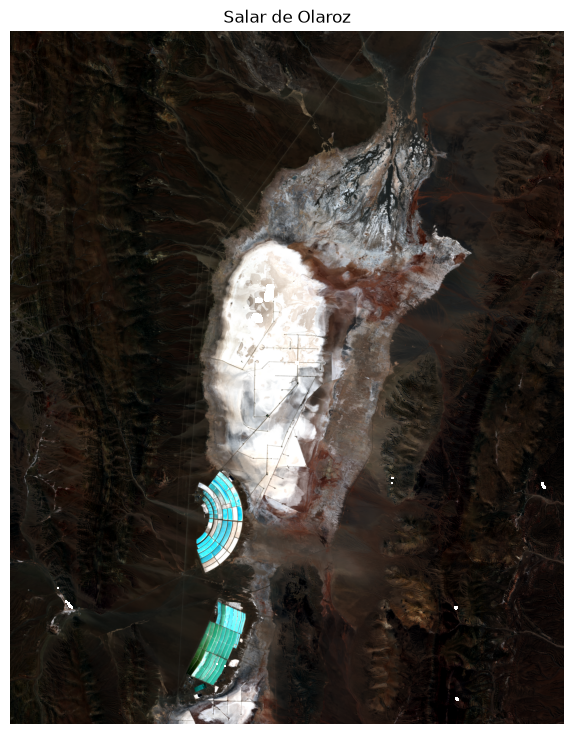

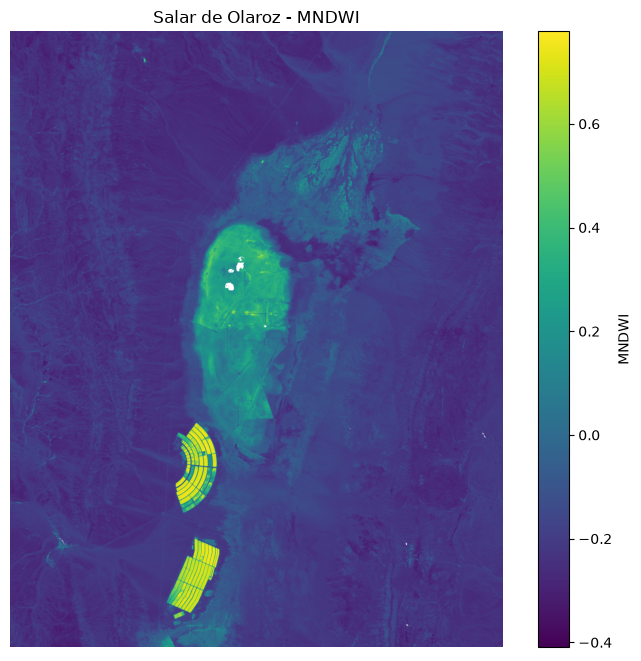

In [40]:
#Ejemplos:

plot_rgb(
    result_olaroz
)

plot_index(
    result_olaroz,
    "MNDWI",
)

# 22. Estructura de salida esperada

```text
cache/
└── sentinel2_daily/
    ├── olaroz/daily/
    ├── cauchari/daily/
    │   ├── 2025-06-05_spectral.tif
    │   ├── 2025-06-05_valid_mask.tif
    │   ├── 2025-06-05_manifest.json
    │   └── ...
    └── hombre_muerto/daily/

raster/
├── olaroz/
│   ├── olaroz_sentinel2_spectral_median.tif
│   ├── olaroz_sentinel2_features_median.tif
│   ├── olaroz_qa_valid_count.tif
│   └── olaroz_qa_valid_fraction.tif
├── cauchari/
└── hombre_muerto/

metadata/
├── olaroz/
│   ├── candidate_scenes.csv
│   ├── coverage_by_date.csv
│   ├── selected_scenes.csv
│   ├── daily_processing_report.csv
│   ├── processing_events.jsonl
│   └── acquisition_protocol.json
├── cauchari/
└── hombre_muerto/

labels/
├── olaroz/olaroz_aoi_rectangular.geojson
├── cauchari/cauchari_aoi_rectangular.geojson
└── hombre_muerto/hombre_muerto_aoi_rectangular.geojson
```

El cache diario es deliberadamente persistente: actúa como checkpoint y como insumo auditable para reconstruir el compuesto final sin volver a descargar Sentinel-2.


# 23. Diseño experimental recomendado para ML clásico

No conviene limitarse a un split aleatorio de píxeles.

Los píxeles vecinos están espacialmente autocorrelacionados y un split aleatorio puede producir métricas demasiado optimistas.

## Experimento A — intra-Olaroz

Separar espacialmente los polígonos o bloques:

```text
Train: sectores A + B + C
Test:  sector D
```

## Experimento B — transferencia cercana

```text
Train: Olaroz
Test:  Cauchari
```

## Experimento C — transferencia externa

```text
Train: Olaroz + Cauchari
Test:  Hombre Muerto
```

## Experimento D — Leave-One-Salar-Out

```text
Fold 1:
Train = Cauchari + Hombre Muerto
Test  = Olaroz

Fold 2:
Train = Olaroz + Hombre Muerto
Test  = Cauchari

Fold 3:
Train = Olaroz + Cauchari
Test  = Hombre Muerto
```

Métricas recomendadas:

- F1 macro
- precision/recall por clase
- balanced accuracy
- matriz de confusión
- Cohen's kappa como métrica complementaria

Modelos iniciales:

- Random Forest
- Extra Trees
- HistGradientBoosting
- SVM

# 24. Extensiones futuras sobre una base ya reanudable

Una vez estabilizados los tres dominios con v5:

## Datos

- percentiles temporales p10/p50/p90;
- amplitud temporal NDVI/NDWI;
- Sentinel-1 SAR;
- DEM y derivados geomorfológicos;
- variables climáticas/evaporíticas si son metodológicamente pertinentes.

## Modelado

- split espacial por bloques;
- validación cruzada espacial;
- transferencia Olaroz → Cauchari → Hombre Muerto;
- calibración de probabilidades e incertidumbre;
- aprendizaje activo para optimizar nuevas etiquetas.

## Escalado

- cache por bloque espacial si los AOI crecen mucho más;
- ejecución Dask distribuida cerca de la región de almacenamiento;
- catálogos STAC propios de productos intermedios;
- Zarr/COG para series temporales extensas;
- checksum/registro de artefactos para experimentos de producción.


# 25. Checklist antes de entrenar ML

- [ ] Los tres AOI fueron revisados en QGIS.
- [ ] La superposición Olaroz/Cauchari fue considerada al diseñar train/test.
- [ ] Las fechas seleccionadas pertenecen a una ventana estacional comparable.
- [ ] `daily_processing_report.csv` no muestra fechas faltantes.
- [ ] Todos los manifests diarios tienen `status = complete`.
- [ ] `qa_valid_fraction` fue inspeccionado antes del muestreo ML.
- [ ] Los rangos de reflectancia son plausibles.
- [ ] Los índices están dentro de rangos razonables y con NaN donde corresponde.
- [ ] El split evita fuga espacial entre píxeles vecinos.
- [ ] `acquisition_protocol.json` se conserva junto con los resultados del experimento.
